# Scaling and Normalization

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mlxtend.preprocessing import minmax_scaling

np.random.seed(0)

# Scaling

In scaling, you're changing the range of your data.

By scaling your variables, you can help compare different variables on equal footing.

Text(0.5, 1.0, 'Scaled data')

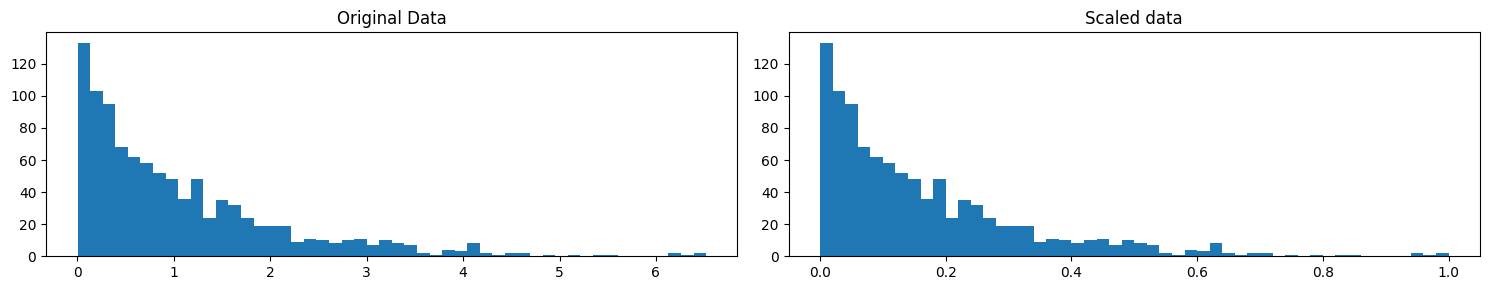

In [6]:
# generate 1000 data points randomly drawn from an exponential distribution
original_data = np.random.exponential(size=1000)

# mix-max scale the data between 0 and 1
scaled_data = minmax_scaling(original_data, columns=[0])

# plot both together to compare
fig, ax = plt.subplots(1, 2, figsize=(15, 3), tight_layout=True)
n_bins = 50
ax[0].hist(original_data, bins=n_bins)
ax[0].set_title("Original Data")
ax[1].hist(scaled_data, bins=n_bins)
ax[1].set_title("Scaled data")

Notice that the shape of the data doesn't change, but that instead of ranging from 0 to 8ish, it now ranges from 0 to 1.

# Normalization

Scaling just changes the range of your data. Normalization is a more radical transformation. The point of normalization is to change your observations so that they can be described as a normal distribution.

**Normal distribution**: Also known as the "bell curve", this is a specific statistical distribution where a roughly equal observations fall above and below the mean, the mean and the median are the same, and there are more observations closer to the mean. The normal distribution is also known as the Gaussian distribution.

# exercise

In [11]:
kickstarters_2017 = pd.read_csv("../input/ks-projects-201801.csv")
np.random.seed(0)

In [16]:
# select the usd_goal_real column
original_data = pd.DataFrame(kickstarters_2017.usd_goal_real)

# scale the goals from 0 to 1
scaled_data = minmax_scaling(original_data, columns=['usd_goal_real'])

print('Original data\nPreview:\n', original_data.head())
print('Minimum value:', original_data.min(), '\nMaximum value:', original_data.max())
print('_' * 30)

print('\nScaled data\nPreview:\n', scaled_data.head())
print('Minimum value:', scaled_data.min(), '\nMaximum value:', scaled_data.max())

Original data
Preview:
    usd_goal_real
0        1533.95
1       30000.00
2       45000.00
3        5000.00
4       19500.00
Minimum value: usd_goal_real    0.01
dtype: float64 
Maximum value: usd_goal_real    1.663614e+08
dtype: float64
______________________________

Scaled data
Preview:
    usd_goal_real
0       0.000009
1       0.000180
2       0.000270
3       0.000030
4       0.000117
Minimum value: usd_goal_real    0.0
dtype: float64 
Maximum value: usd_goal_real    1.0
dtype: float64


In [17]:
original_goal_data = pd.DataFrame(kickstarters_2017.goal)
original_goal_data.head()

,goal
0,1000.0
1,30000.0
2,45000.0
3,5000.0
4,19500.0


In [18]:
scaled_goal_data = minmax_scaling(original_goal_data, columns=['goal'])

print('Minimum value:', original_data.min(), '\nMaximum value:', original_data.max())
print('_' * 30)
print('Minimum value:', scaled_data.min(), '\nMaximum value:', scaled_data.max())

Minimum value: usd_goal_real    0.01
dtype: float64 
Maximum value: usd_goal_real    1.663614e+08
dtype: float64
______________________________
Minimum value: usd_goal_real    0.0
dtype: float64 
Maximum value: usd_goal_real    1.0
dtype: float64


### normalization

In [21]:
# for Box-Cox Transformation
from scipy import stats

# get the index of all positive pledges (Box-Cox only takes positive values)
index_of_positive_pledges = kickstarters_2017.usd_pledged_real > 0

# get only positive pledges (using their indexes)
positive_pledges = kickstarters_2017.usd_pledged_real.loc[index_of_positive_pledges]

# normalize the pledges (w/ Box-Cox)
normalized_pledges = pd.Series(stats.boxcox(positive_pledges)[0],
                               name='usd_pledged_real', index=positive_pledges.index)

print('Original data')
print('Minimum value:', float(positive_pledges.min()),
      '\nMaximum value:', float(positive_pledges.max()))
print('_'*30)

print('\nNormalized data')
print('Minimum value:', float(normalized_pledges.min()),
      '\nMaximum value:', float(normalized_pledges.max()))

Original data
Minimum value: 0.45 
Maximum value: 20338986.27
______________________________

Normalized data
Minimum value: -0.7779954094203855 
Maximum value: 30.690543030685514


Text(0.5, 1.0, 'Normalized data')

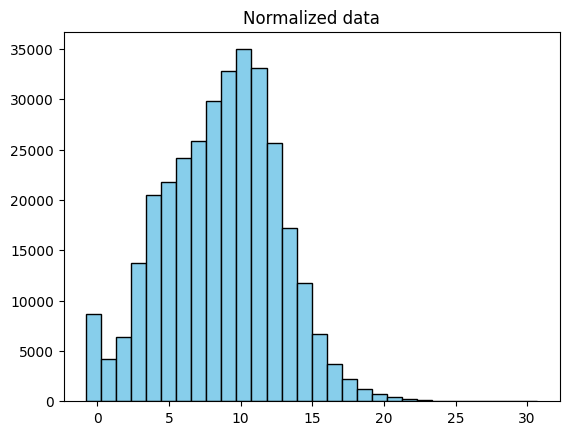

In [23]:
# Generate random data for the histogram
plt.hist(normalized_pledges, bins=30, color='skyblue', edgecolor='black')
plt.title('Normalized data')